In [22]:
import sys
sys.path.insert(1, '..')

import os, yaml, pickle

from physics.simulation import mcfm, msq
from physics.hzz import zpair, zz4l
from physics.hstar import c6
from datasets import coefficient
from models import rolypoly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist
import pandas as pd

import torch
from lightning import Trainer

In [23]:
OUTPUT_DIR = '../jobs/rolypoly/refactor-four-SIG/coeff_2/'
SCALER_FILE_X = 'scaler_X.pkl'
SCALER_FILE_Y = 'scaler_y.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '../..'

checkpoint_epoch = '181'
checkpoint_loss = '0.00'

CHECKPOINT = f'checkpoint-rolypoly-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION_NO = 1
LIGHTNING_DIR = f'lightning_logs/version_{VERSION_NO}'

COMPONENT = msq.Component.SIG
COMPONENT_FILE = msq.Component.SIG

FEATURES = ['mandelstam_s', 'mandelstam_t', 'mandelstam_u']#['cth_star', 'cth_1', 'cth_2', 'phi', 'phi_1', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']
COEFFICIENT_INDEX = 2
SAMPLE_SIZE = 50000
BATCH_SIZE = 64
SEED = 42

In [24]:
with open(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'hparams.yaml'), 'r') as f:
    params = yaml.load(f, Loader=yaml.CLoader)

In [25]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [26]:
sample = mcfm.from_csv(cross_section=1.0, file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_FILE]), n_rows=250000).reweight(COMPONENT_FILE, COMPONENT)
        
z_cand = zpair.ZPairCandidate(algorithm='truth')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
mandelstam = zz4l.MandelstamVariables()
angles = zz4l.AngularVariables()
fourlepton = zz4l.FourLeptonSystem()

sample = sample.calculate(z_cand).filter(z_masses).calculate(mandelstam).calculate(angles).calculate(fourlepton)

0.1256839601908204


In [27]:
c6_mod = c6.Modifier(baseline=COMPONENT, events=sample, c6_values=[-5,-1,0,1,5]) if COMPONENT!=msq.Component.INT else c6.Modifier(baseline=COMPONENT, events=sample, c6_values=[-5,0,5])
coefficient = c6_mod.coefficients[:,COEFFICIENT_INDEX]

unweighted_indices = sample.weights.sample(n=SAMPLE_SIZE, replace=True, weights=sample.weights, random_state=SEED).index
        
X = sample.kinematics[FEATURES].to_numpy()[unweighted_indices]

with open(os.path.join(OUTPUT_DIR, SCALER_FILE_X), 'rb') as f:
    scaler_X = pickle.load(f)

X = torch.tensor(scaler_X.transform(X), dtype=torch.float32).cpu()
y = coefficient[unweighted_indices]

In [28]:
print(np.median(y))

5.232442458337179e-06


In [29]:
loaded_model = rolypoly.ROLYPOLY.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [30]:
predictions = loaded_model(X).detach().view(-1).numpy()

In [31]:
with open(os.path.join(OUTPUT_DIR, SCALER_FILE_Y), 'rb') as f:
    scaler_y = pickle.load(f)

predictions = scaler_y.inverse_transform(predictions[:,np.newaxis]).flatten()

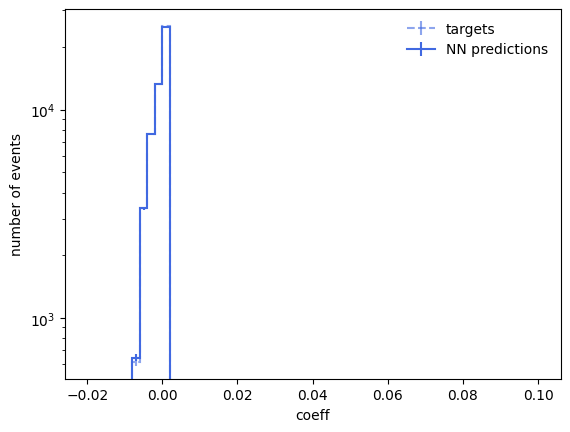

In [32]:
BINS = 60

bounds = [-2e-2,10e-2]
#bounds = [-1e-6,1.4e-5]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
#y[y>=0] = -y[y>=0]
h_targets_train.fill(y)

h_targets_train.plot(color='royalblue', linestyle='--', label='targets', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions')

plt.xlabel(f'coeff')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend(frameon=False)

plt.show()

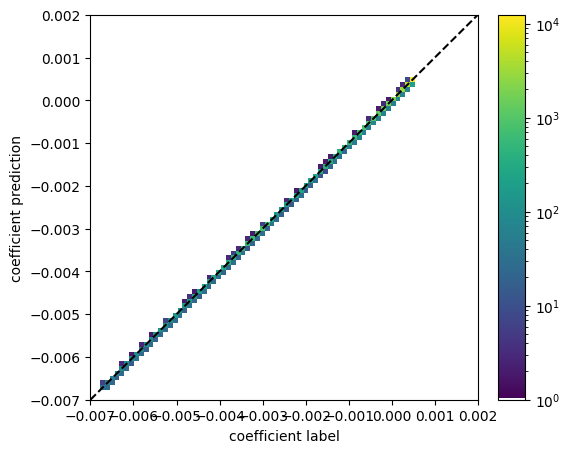

In [39]:
BINS=80

bounds = [-7e-3,2e-3]
#bounds = [-1e-6,1.4e-5]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='coefficient label'),
    hist.axis.Regular(BINS, *bounds, name='coefficient prediction')
)

h_calibration_train.fill(y, predictions)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig = plt.figure(figsize=(5,5))

h_calibration_train.plot2d(cmap=cmap, cbar=True, norm=LogNorm())
plt.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')


plt.show()

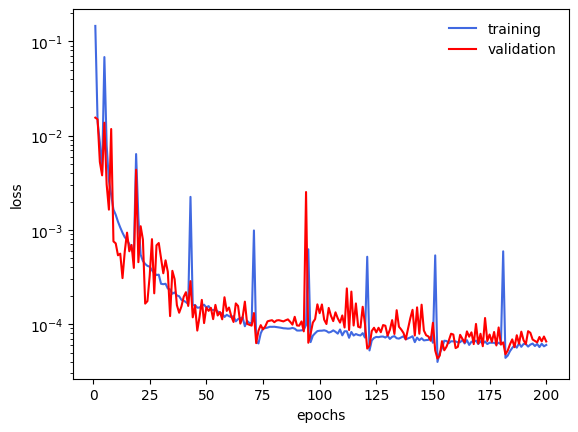

In [34]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs+1, train_loss, color='royalblue', label='training')
plt.plot(epochs+1, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.xscale('log')
plt.yscale('log')
plt.legend(frameon=False)
plt.show()